# Bài tập Buổi 6 — Cây Quyết Định & Rừng Ngẫu Nhiên (Decision Tree & Random Forest)

**Sinh viên thực hiện:** "Your Name"

---

## Bối cảnh

Trong bài tập này, bạn đang đóng vai trò là một Data Scientist làm việc tại một trung tâm nghiên cứu ung thư. Bạn được giao nhiệm vụ phân tích bộ dữ liệu **Breast Cancer Wisconsin (Diagnostic)**, chứa các thông số đo lường từ hình ảnh sinh thiết tế bào của các bệnh nhân.

Mục tiêu của bài toán là xây dựng mô hình học máy để phân loại khối u là **Lành tính (Benign)** hay **Ác tính (Malignant)**.

**Lưu ý quan trọng:** Trong bài toán chẩn đoán ung thư, việc chẩn đoán sót một khối u ác tính thành lành tính (False Negative) mang lại hậu quả nghiêm trọng hơn rất nhiều so với việc chẩn đoán nhầm lành tính thành ác tính (False Positive). Do đó, chúng ta sẽ đặc biệt quan tâm đến chỉ số **Recall**.

## Mục tiêu bài tập

1. Hiểu và xử lý bộ dữ liệu y khoa cơ bản với nhiều đặc trưng dạng số liên tục.
2. Huấn luyện mô hình **Decision Tree** và trực quan hóa các ranh giới quyết định (Decision Boundaries) thông qua cấu trúc cây.
3. Xây dựng mô hình **Random Forest** và đánh giá độ quan trọng của các đặc trưng (Feature Importance) trong việc chẩn đoán.
4. Phân tích chuyên sâu về các độ đo **Recall, F1-Score** và **Confusion Matrix** thay vì chỉ phụ thuộc vào Accuracy.

## Tiêu chí chấm (10 điểm)

| Task | Nội dung | Điểm |
|---|---|---|
| **1** | EDA & Thống kê dữ liệu tổng quan | 1.0 |
| **2** | Trực quan hóa tương quan dữ liệu | 2.0 |
| **3** | Chia tập & Scaling | 1.0 |
| **4** | Huấn luyện Decision Tree & Trực quan hóa cây | 2.0 |
| **5** | Huấn luyện Random Forest & Feature Importance | 2.0 |
| **6** | Đánh giá Confusion Matrix, Recall, F1-score và rút ra Insight | 2.0 |

---


## 0. Chuẩn bị môi trường & Nạp dữ liệu

Dữ liệu được tích hợp sẵn trong thư viện `scikit-learn`. Chạy ô bên dưới để tải và hiển thị.

In [1]:
pip install numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)
np.random.seed(RANDOM_STATE)

cancer_data = load_breast_cancer()

df = pd.DataFrame(
    cancer_data.data,
    columns=cancer_data.feature_names,
)
df["target"] = cancer_data.target

print("Kích thước bộ dữ liệu:", df.shape)
print("Số đặc trưng:", len(cancer_data.feature_names))
print("Ý nghĩa target:", dict(enumerate(cancer_data.target_names)))
display(df.head())

Kích thước bộ dữ liệu: (569, 31)
Số đặc trưng: 30
Ý nghĩa target: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.589,153.40,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.398,74.08,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,0
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.585,94.03,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,0
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.445,27.23,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,0
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.438,94.44,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,0


---
## Task 1 — EDA và Kiểm tra Dữ liệu Cơ Bản

### Yêu cầu:
1. In ra số lượng mẫu dữ liệu cho từng lớp (0: Ác tính, 1: Lành tính) bằng `value_counts()`.
2. Kiểm tra xem dữ liệu có giá trị khuyết thiếu (NaN) nào không.
3. Nêu nhận xét về sự cân bằng của bộ dữ liệu.

### Gợi ý:
- Sử dụng cú pháp `df['tên_cột'].value_counts()` để đếm số lượng nhãn.
- Để kiểm tra missing value trên toàn bộ dataframe, bạn có thể kết hợp `.isnull().sum()`.

In [12]:
class_counts = (
    df["target"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Malignant (0)", 1: "Benign (1)"})
)

class_ratios = (
    df["target"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename(index={0: "Malignant (0)", 1: "Benign (1)"})
)

missing_by_column = df.isna().sum()
total_missing = int(missing_by_column.sum())

print("Số mẫu theo lớp:")
display(class_counts.to_frame("Số mẫu"))

print("Tỷ lệ theo lớp:")
display(class_ratios.round(2).to_frame("Tỷ lệ (%)"))

print("Tổng số giá trị thiếu:", total_missing)

if total_missing > 0:
    display(
        missing_by_column[
            missing_by_column > 0
        ].to_frame("Số giá trị thiếu")
    )
else:
    print("Không có cột nào chứa giá trị thiếu.")

Số mẫu theo lớp:


,Số mẫu
target,
Malignant (0),212
Benign (1),357


Tỷ lệ theo lớp:


,Tỷ lệ (%)
target,
Malignant (0),37.26
Benign (1),62.74


Tổng số giá trị thiếu: 0
Không có cột nào chứa giá trị thiếu.


In [13]:
from IPython.display import Markdown, display

malignant_count = int((df["target"] == 0).sum())
benign_count = int((df["target"] == 1).sum())

malignant_ratio = malignant_count / len(df) * 100
benign_ratio = benign_count / len(df) * 100

task1_comment = f"""
**Nhận xét Task 1**

- Bộ dữ liệu có **{len(df)} mẫu**.
- Lớp ác tính có **{malignant_count} mẫu**, chiếm **{malignant_ratio:.2f}%**.
- Lớp lành tính có **{benign_count} mẫu**, chiếm **{benign_ratio:.2f}%**.
- Dữ liệu lệch về lớp lành tính. Khi chia train/test cần dùng `stratify=y` để giữ tỷ lệ hai lớp.
- Tổng số giá trị thiếu là **{total_missing}**.
"""

display(Markdown(task1_comment))


**Nhận xét Task 1**

- Bộ dữ liệu có **569 mẫu**.
- Lớp ác tính có **212 mẫu**, chiếm **37.26%**.
- Lớp lành tính có **357 mẫu**, chiếm **62.74%**.
- Dữ liệu lệch về lớp lành tính. Khi chia train/test cần dùng `stratify=y` để giữ tỷ lệ hai lớp.
- Tổng số giá trị thiếu là **0**.


---
## Task 2 — Trực quan hóa Dữ liệu Y khoa

Bộ dữ liệu có tới 30 đặc trưng, chúng ta sẽ khảo sát một vài đặc trưng cơ bản.

### Yêu cầu:
1. Vẽ biểu đồ **Boxplot** so sánh phân phối của biến `mean radius` (bán kính trung bình của tế bào) giữa 2 lớp Khối u (Ác tính và Lành tính).
2. Vẽ biểu đồ **Scatter plot** giữa `mean radius` (trục x) và `mean texture` (trục y), tô màu (hue) theo cột `target`.
3. Có thể dùng 2 đặc trưng này để phân định ranh giới cơ bản giữa khối u lành/ác được không? Vì sao?

### Gợi ý:
- Vẽ Boxplot: `sns.boxplot(data=df, x='target', y='mean radius')`.
- Vẽ Scatter plot: `sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='target')`.

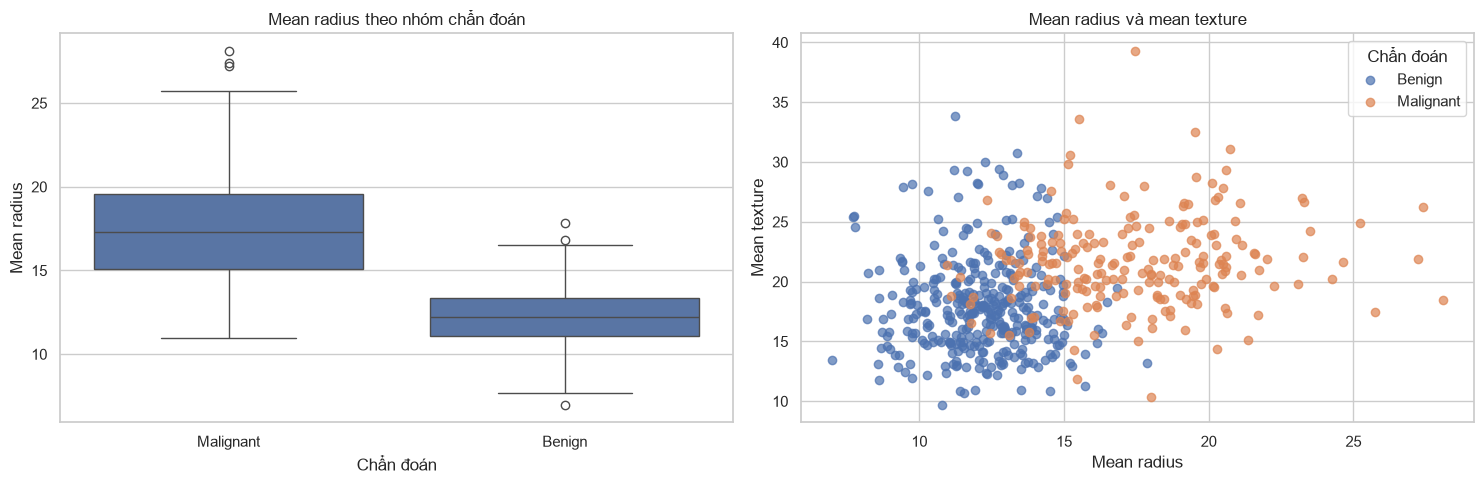

mean radius         mean texture        
               median    mean       median    mean
diagnosis                                         
Benign         12.200  12.147        17.39  17.915
Malignant      17.325  17.463        21.46  21.605

In [14]:
label_map = {
    0: "Malignant",
    1: "Benign",
}

plot_df = df.copy()
plot_df["diagnosis"] = plot_df["target"].map(label_map)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=plot_df,
    x="diagnosis",
    y="mean radius",
    ax=axes[0],
)
axes[0].set_title("Mean radius theo nhóm chẩn đoán")
axes[0].set_xlabel("Chẩn đoán")
axes[0].set_ylabel("Mean radius")

for diagnosis, group in plot_df.groupby("diagnosis"):
    axes[1].scatter(
        group["mean radius"],
        group["mean texture"],
        alpha=0.7,
        label=diagnosis,
    )

axes[1].set_title("Mean radius và mean texture")
axes[1].set_xlabel("Mean radius")
axes[1].set_ylabel("Mean texture")
axes[1].legend(title="Chẩn đoán")

plt.tight_layout()
plt.show()

task2_summary = (
    plot_df
    .groupby("diagnosis")[["mean radius", "mean texture"]]
    .agg(["median", "mean"])
)

display(task2_summary.round(3))

In [17]:
malignant_radius_median = df.loc[
    df["target"] == 0,
    "mean radius",
].median()

benign_radius_median = df.loc[
    df["target"] == 1,
    "mean radius",
].median()

malignant_texture_median = df.loc[
    df["target"] == 0,
    "mean texture",
].median()

benign_texture_median = df.loc[
    df["target"] == 1,
    "mean texture",
].median()

task2_comment = f"""
**Nhận xét Task 2**

- Median `mean radius` của lớp ác tính là **{malignant_radius_median:.3f}**, cao hơn lớp lành tính **{benign_radius_median:.3f}**.
- Median `mean texture` của lớp ác tính là **{malignant_texture_median:.3f}**, cao hơn lớp lành tính **{benign_texture_median:.3f}**.
- Boxplot cho thấy `mean radius` tạo độ phân tách rõ giữa hai lớp.
- Scatter plot vẫn có vùng chồng lấn. Hai đặc trưng này hỗ trợ phân loại cơ bản nhưng chưa đủ để phân tách hoàn toàn.
"""

display(Markdown(task2_comment))


**Nhận xét Task 2**

- Median `mean radius` của lớp ác tính là **17.325**, cao hơn lớp lành tính **12.200**.
- Median `mean texture` của lớp ác tính là **21.460**, cao hơn lớp lành tính **17.390**.
- Boxplot cho thấy `mean radius` tạo độ phân tách rõ giữa hai lớp.
- Scatter plot vẫn có vùng chồng lấn. Hai đặc trưng này hỗ trợ phân loại cơ bản nhưng chưa đủ để phân tách hoàn toàn.


---
## Task 3 — Chia Tập Dữ Liệu và Tiền Xử Lý

### Yêu cầu:
1. Tách đặc trưng (X) và nhãn (y).
2. Chia tập Train/Test theo tỷ lệ **75/25**, `stratify=y`, và `random_state=42`.
3. Mặc dù Decision Tree và Random Forest không yêu cầu chuẩn hóa (Scaling), nhưng việc có `StandardScaler` sẽ giúp dễ dàng so sánh với các thuật toán khác (như SVM/Logistic Regression) sau này. Hãy fit `StandardScaler` trên `X_train` và transform cho cả `X_train` và `X_test`.

### Gợi ý:
- Sử dụng hàm `train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)`.
- **Nguyên tắc chống Data Leakage:** Chỉ dùng phương thức `.fit_transform()` trên tập `X_train`, nhưng chỉ được dùng phương thức `.transform()` trên tập `X_test`.

In [16]:
RANDOM_STATE = 42

X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("Phân bố y_train:")
display(
    y_train
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_frame("Tỷ lệ (%)")
)

print("Phân bố y_test:")
display(
    y_test
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_frame("Tỷ lệ (%)")
)

print(
    "Mean tuyệt đối lớn nhất sau scaling trên train:",
    f"{np.abs(X_train_scaled.mean(axis=0)).max():.6f}",
)

X_train: (426, 30)
X_test: (143, 30)
Phân bố y_train:


,Tỷ lệ (%)
target,
0,37.32
1,62.68


Phân bố y_test:


,Tỷ lệ (%)
target,
0,37.06
1,62.94


Mean tuyệt đối lớn nhất sau scaling trên train: 0.000000


---
## Task 4 — Huấn luyện Cây Quyết Định (Decision Tree)

### Yêu cầu:
1. Khởi tạo và huấn luyện `DecisionTreeClassifier(max_depth=3, random_state=42)` trên tập Train.
2. Sử dụng `plot_tree` để vẽ cấu trúc cây.
3. Nút gốc (Root Node) đang dùng đặc trưng nào để chia nhánh dữ liệu đầu tiên? Bạn có nghĩ đó là đặc trưng quan trọng nhất không?

### Gợi ý:
- Khởi tạo mô hình: `dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)`.
- Đừng quên gọi `.fit(X_train_scaled, y_train)` trước khi thực hiện vẽ sơ đồ cây.

Đặc trưng tại nút gốc: worst radius
Ngưỡng sau scaling: 0.1234
Ngưỡng theo đơn vị gốc: 16.7950


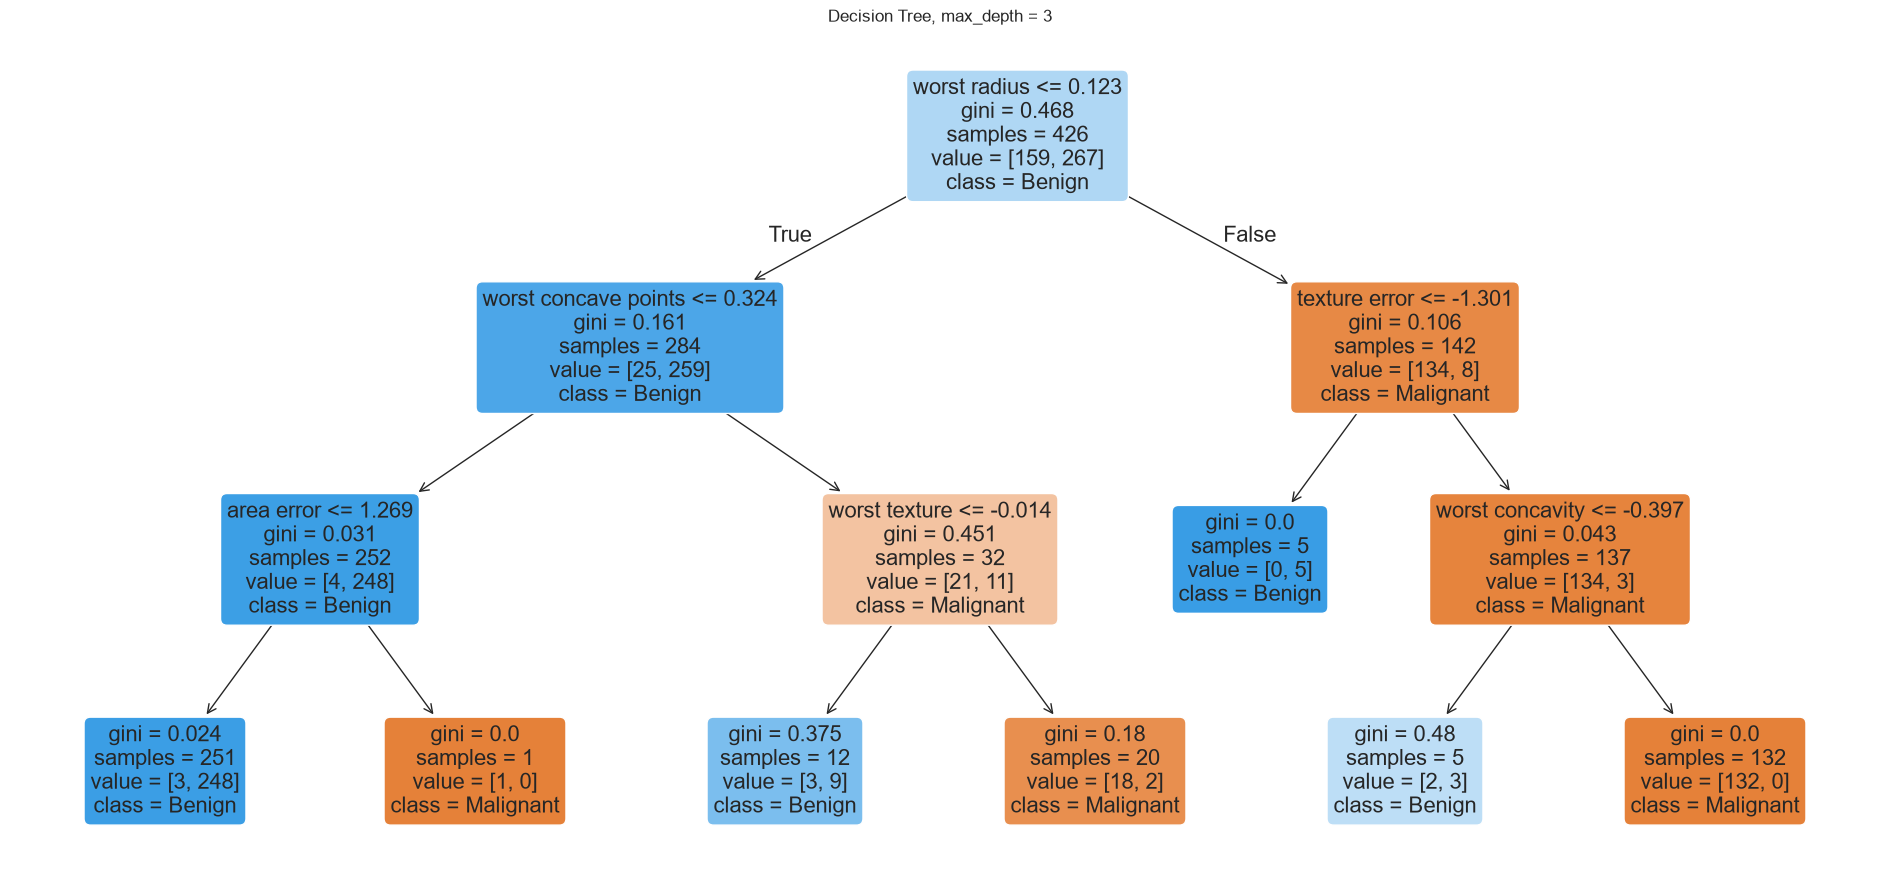

In [20]:
RANDOM_STATE = 42

dt_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE,
)

dt_model.fit(X_train_scaled, y_train)

root_feature_index = int(dt_model.tree_.feature[0])
root_feature_name = cancer_data.feature_names[root_feature_index]
root_threshold_scaled = float(dt_model.tree_.threshold[0])

root_threshold_original = (
    root_threshold_scaled * scaler.scale_[root_feature_index]
    + scaler.mean_[root_feature_index]
)

print("Đặc trưng tại nút gốc:", root_feature_name)
print("Ngưỡng sau scaling:", f"{root_threshold_scaled:.4f}")
print("Ngưỡng theo đơn vị gốc:", f"{root_threshold_original:.4f}")

plt.figure(figsize=(24, 11))
plot_tree(
    dt_model,
    feature_names=cancer_data.feature_names,
    class_names=["Malignant", "Benign"],
    filled=True,
    rounded=True,
    precision=3,
)
plt.title("Decision Tree, max_depth = 3")
plt.show()

In [21]:
from IPython.display import Markdown, display

dt_importance = pd.Series(
    dt_model.feature_importances_,
    index=cancer_data.feature_names,
).sort_values(ascending=False)

task4_comment = f"""
**Nhận xét Task 4**

- Nút gốc chia theo đặc trưng **`{root_feature_name}`**.
- Ngưỡng chia xấp xỉ theo dữ liệu gốc là **{root_threshold_original:.4f}**.
- Cây chọn đặc trưng này vì phép chia tại nút gốc làm giảm impurity nhiều nhất trên tập train.
- Ba đặc trưng có importance cao nhất trong cây này là **{", ".join(dt_importance.head(3).index.tolist())}**.
- Đặc trưng ở nút gốc quan trọng đối với cây hiện tại, nhưng chưa đủ để kết luận luôn là đặc trưng quan trọng nhất trong mọi mô hình.
"""

display(Markdown(task4_comment))


**Nhận xét Task 4**

- Nút gốc chia theo đặc trưng **`worst radius`**.
- Ngưỡng chia xấp xỉ theo dữ liệu gốc là **16.7950**.
- Cây chọn đặc trưng này vì phép chia tại nút gốc làm giảm impurity nhiều nhất trên tập train.
- Ba đặc trưng có importance cao nhất trong cây này là **worst radius, worst concave points, texture error**.
- Đặc trưng ở nút gốc quan trọng đối với cây hiện tại, nhưng chưa đủ để kết luận luôn là đặc trưng quan trọng nhất trong mọi mô hình.


---
## Task 5 — Rừng Ngẫu Nhiên & Độ Quan Trọng của Đặc Trưng

### Yêu cầu:
1. Khởi tạo và huấn luyện `RandomForestClassifier(n_estimators=100, random_state=42)`.
2. Lấy ra mức độ quan trọng của từng đặc trưng (`feature_importances_`).
3. Vẽ biểu đồ **Bar plot ngang (Horizontal Barplot)** hiển thị **Top 10 đặc trưng quan trọng nhất** theo đánh giá của Random Forest.

### Gợi ý:
- Tạo DataFrame để dễ dàng sắp xếp: `imp_df = pd.DataFrame({'Feature': cancer_data.feature_names, 'Importance': rf_model.feature_importances_})`.
- Sắp xếp giảm dần: `imp_df = imp_df.sort_values(by='Importance', ascending=False)`.
- Lấy 10 dòng đầu (`.head(10)`) và đưa vào hàm `sns.barplot(data=..., x='Importance', y='Feature')` để vẽ.

,Feature,Importance
0,worst area,0.1497
1,worst concave points,0.1272
2,mean concave points,0.1046
3,worst radius,0.0870
4,worst perimeter,0.0803
5,mean perimeter,0.0800
6,mean concavity,0.0554
7,mean radius,0.0537
8,mean area,0.0441
9,area error,0.0246


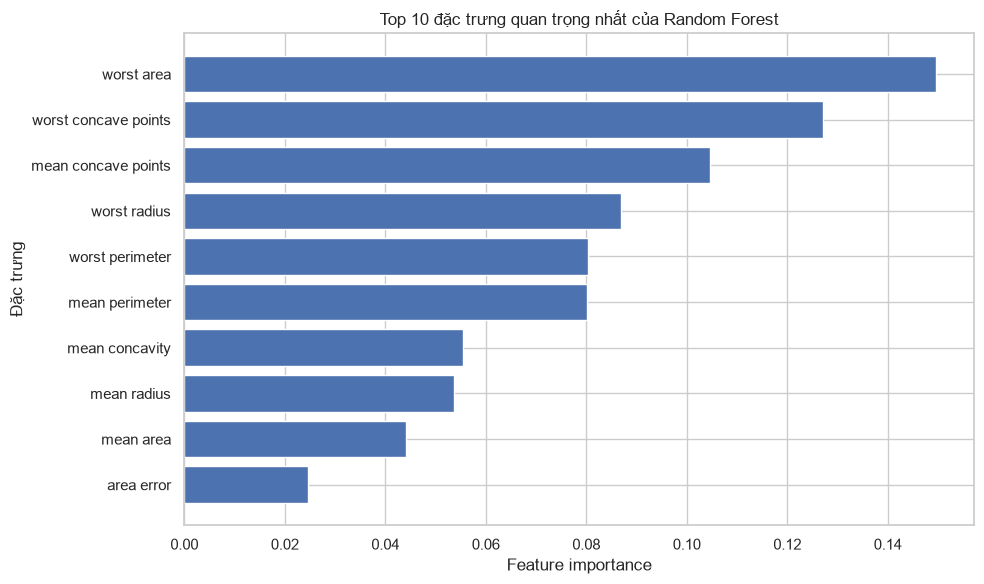


**Nhận xét Task 5**

- Đặc trưng có importance cao nhất là **`worst area`**, với giá trị **0.1497**.
- Feature importance phản ánh mức giảm impurity trung bình do từng đặc trưng tạo ra trong các cây.
- Importance không chứng minh quan hệ nhân quả và có thể phân tán giữa các đặc trưng tương quan.


In [22]:
RANDOM_STATE = 42

from IPython.display import Markdown, display

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
)

rf_model.fit(X_train_scaled, y_train)

imp_df = pd.DataFrame({
    "Feature": cancer_data.feature_names,
    "Importance": rf_model.feature_importances_,
}).sort_values(
    by="Importance",
    ascending=False,
    ignore_index=True,
)

top10_features = imp_df.head(10).copy()
display(top10_features.round(4))

plot_data = top10_features.sort_values(
    by="Importance",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["Feature"],
    plot_data["Importance"],
)
plt.title("Top 10 đặc trưng quan trọng nhất của Random Forest")
plt.xlabel("Feature importance")
plt.ylabel("Đặc trưng")
plt.tight_layout()
plt.show()

top_feature = top10_features.iloc[0]

task5_comment = f"""
**Nhận xét Task 5**

- Đặc trưng có importance cao nhất là **`{top_feature["Feature"]}`**, với giá trị **{top_feature["Importance"]:.4f}**.
- Feature importance phản ánh mức giảm impurity trung bình do từng đặc trưng tạo ra trong các cây.
- Importance không chứng minh quan hệ nhân quả và có thể phân tán giữa các đặc trưng tương quan.
"""

display(Markdown(task5_comment))

---
## Task 6 — Đánh giá Mô Hình chuyên sâu (Confusion Matrix, Recall, F1)

Trong bài toán này:
*   **Class 0 (Malignant - Ác tính)** là lớp chúng ta cực kỳ muốn tìm ra.
*   **Class 1 (Benign - Lành tính)** là lớp ít nguy hiểm hơn.

**Recall của lớp 0** cho biết: Trong tổng số những người thực sự mắc bệnh ung thư ác tính, mô hình đã "bắt" được bao nhiêu phần trăm?

### Yêu cầu:
1. Dự đoán trên tập Test bằng mô hình Random Forest ở Task 5.
2. Vẽ **Confusion Matrix**.
3. In `classification_report` và phân tích kết quả của `Recall` và `F1-Score` đặc biệt cho lớp 0 (Malignant).
4. Mô hình hiện tại của bạn đã bỏ sót bao nhiêu bệnh nhân có khối u ác tính trên tập Test (False Negative)? Con số này đã đủ tốt để triển khai thực tế chưa?

### Gợi ý:
- Lệnh dự đoán: `y_pred_rf = rf_model.predict(X_test_scaled)`.
- Dùng hàm `confusion_matrix(y_test, y_pred_rf)` kết hợp với `ConfusionMatrixDisplay` (đã import ở ô đầu tiên) để vẽ.
- Cần cẩn thận khi đọc Confusion Matrix: Dựa vào các trục Thực tế (True label) và Dự đoán (Predicted label), hãy nhìn vào ô có `Thực tế = 0` nhưng `Dự đoán = 1` để tìm số ca bị bỏ sót.

Classification Report:
               precision    recall  f1-score   support

Malignant (0)     0.9608    0.9245    0.9423        53
   Benign (1)     0.9565    0.9778    0.9670        90

     accuracy                         0.9580       143
    macro avg     0.9587    0.9512    0.9547       143
 weighted avg     0.9581    0.9580    0.9579       143



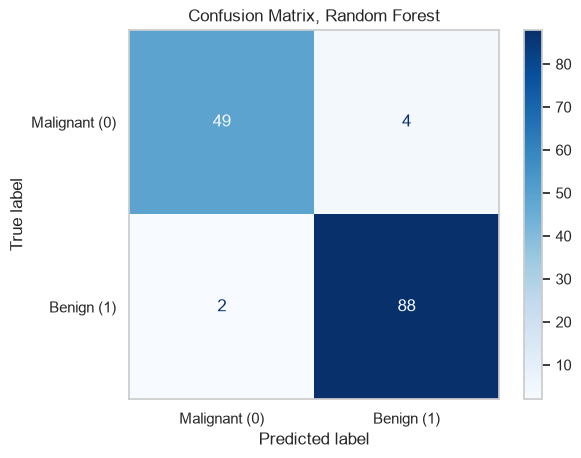

,Metric,Value
0,Accuracy,0.9580
1,"Precision, lớp 0",0.9608
2,"Recall, lớp 0",0.9245
3,"F1-score, lớp 0",0.9423


In [23]:
y_pred_rf = rf_model.predict(X_test_scaled)

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Malignant (0)",
            "Benign (1)",
        ],
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=[0, 1],
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Malignant (0)",
        "Benign (1)",
    ],
)

disp.plot(
    cmap="Blues",
    values_format="d",
)
plt.title("Confusion Matrix, Random Forest")
plt.grid(False)
plt.show()

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_malignant = precision_score(
    y_test,
    y_pred_rf,
    pos_label=0,
    zero_division=0,
)

recall_malignant = recall_score(
    y_test,
    y_pred_rf,
    pos_label=0,
    zero_division=0,
)

f1_malignant = f1_score(
    y_test,
    y_pred_rf,
    pos_label=0,
    zero_division=0,
)

malignant_correct = int(cm[0, 0])
missed_malignant = int(cm[0, 1])
benign_flagged_malignant = int(cm[1, 0])
benign_correct = int(cm[1, 1])

metrics_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision, lớp 0",
        "Recall, lớp 0",
        "F1-score, lớp 0",
    ],
    "Value": [
        accuracy_rf,
        precision_malignant,
        recall_malignant,
        f1_malignant,
    ],
})

display(metrics_summary.round(4))

In [24]:
from IPython.display import Markdown, display

task6_comment = f"""
**Đánh giá Task 6**

1. Random Forest đạt Accuracy **{accuracy_rf:.4f}** trên **{len(y_test)} mẫu test**.
2. Với lớp ác tính, Precision là **{precision_malignant:.4f}**, Recall là **{recall_malignant:.4f}**, F1-score là **{f1_malignant:.4f}**.
3. Mô hình nhận diện đúng **{malignant_correct}** ca ác tính và bỏ sót **{missed_malignant}** ca ác tính.
4. Mô hình gắn nhầm **{benign_flagged_malignant}** ca lành tính thành ác tính.
5. Trong sàng lọc ung thư, nên ưu tiên giảm số ca ác tính bị bỏ sót. Có thể chấp nhận giảm Precision ở mức hợp lý để tăng Recall lớp 0.
6. Kết quả này chưa đủ để triển khai lâm sàng. Cần kiểm định chéo, dữ liệu ngoài mẫu, hiệu chỉnh ngưỡng và đánh giá bởi chuyên gia y khoa.
"""

display(Markdown(task6_comment))


**Đánh giá Task 6**

1. Random Forest đạt Accuracy **0.9580** trên **143 mẫu test**.
2. Với lớp ác tính, Precision là **0.9608**, Recall là **0.9245**, F1-score là **0.9423**.
3. Mô hình nhận diện đúng **49** ca ác tính và bỏ sót **4** ca ác tính.
4. Mô hình gắn nhầm **2** ca lành tính thành ác tính.
5. Trong sàng lọc ung thư, nên ưu tiên giảm số ca ác tính bị bỏ sót. Có thể chấp nhận giảm Precision ở mức hợp lý để tăng Recall lớp 0.
6. Kết quả này chưa đủ để triển khai lâm sàng. Cần kiểm định chéo, dữ liệu ngoài mẫu, hiệu chỉnh ngưỡng và đánh giá bởi chuyên gia y khoa.
